In [17]:
# ==================================================
# EDA NOTEBOOK – HAM10000 RAW DATASET
# File: notebooks/01_eda_dataset.ipynb
# Mục tiêu: Phân tích toàn diện dữ liệu HAM10000
# Chuẩn học thuật (NCKH / Luận văn / Paper)
# ==================================================


# ==============================
# 0. IMPORT LIBRARIES
# ==============================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter


plt.rcParams['figure.figsize'] = (8, 5)


# ==============================
# 1. PATH CONFIGURATION
# ==============================
HAM_ROOT = "../data/HAM10000"
CSV_PATH = os.path.join(HAM_ROOT, "metadata.csv")
IMG_DIRS = [
    os.path.join(HAM_ROOT, "images"),
    os.path.join(HAM_ROOT, "HAM10000_images_part_2"),
]

In [18]:
# ==============================
# 2. LOAD METADATA
# ==============================
df = pd.read_csv(CSV_PATH)
print("Total samples:", len(df))
display(df.head())

Total samples: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [19]:
# ==============================
# 3. BASIC DATASET OVERVIEW
# ==============================
display(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   dataset       10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


None

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
count,10015,10015,10015,10015,9958.000000,10015,10015,10015
unique,7470,10015,7,4,NaN,3,15,4
top,HAM_0000835,ISIC_0032258,nv,histo,NaN,male,back,vidir_molemax
freq,6,1,6705,5340,NaN,5406,2192,3954
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN,NaN


Class distribution (count & percentage):
nv     6705.0   66.95(%)
mel    1113.0   11.11(%)
bkl    1099.0   10.97(%)
bcc     514.0    5.13(%)
akiec   327.0    3.27(%)
vasc    142.0    1.42(%)
df      115.0    1.15(%)


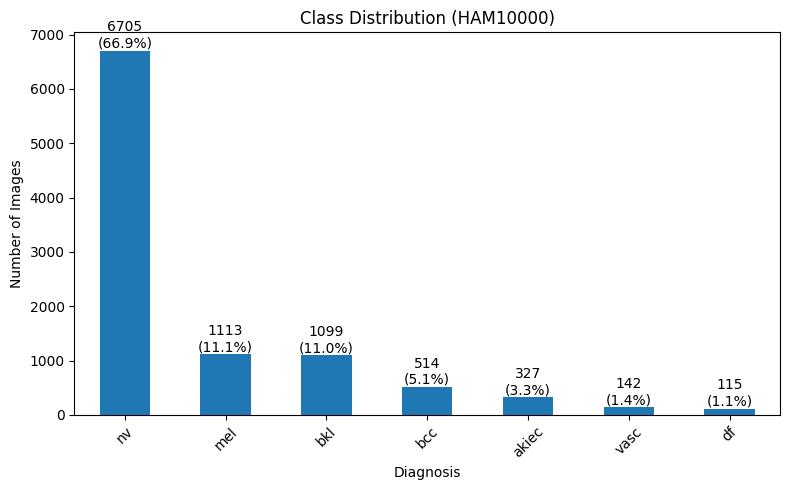


Class imbalance ratio (max/min): 58.30


In [35]:
# ==============================
# 4. CLASS DISTRIBUTION (IMBALANCE)
# ==============================
class_counts = df['dx'].value_counts()
class_percent = class_counts / class_counts.sum() * 100

# Gộp count + percentage
class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent.round(2)
})

print("Class distribution (count & percentage):")
for label, row in class_summary.iterrows():
    print(f"{label:<6} {row['Count']:>6}  {row['Percentage (%)']:>6.2f}(%)")

# Vẽ biểu đồ
plt.figure()
ax = class_counts.plot(kind='bar')

for i, v in enumerate(class_counts):
    pct = class_percent.iloc[i]
    ax.text(i, v, f"{v}\n({pct:.1f}%)", ha='center', va='bottom')

plt.title('Class Distribution (HAM10000)')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Đánh giá mức độ mất cân bằng
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}")



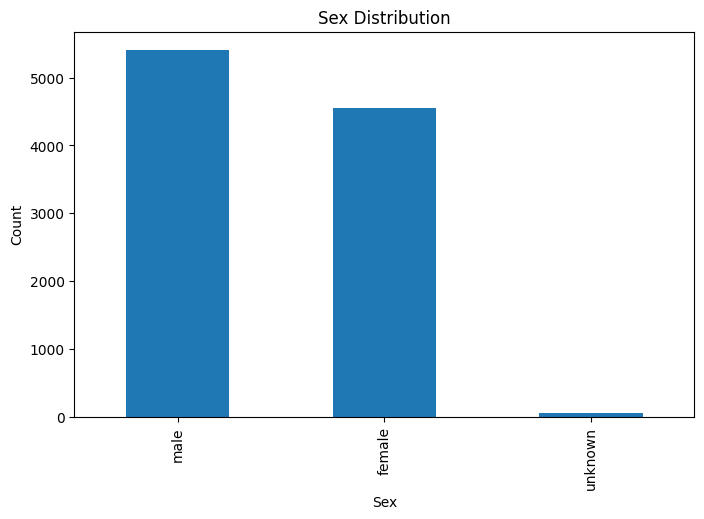

sex,female,male,unknown
dx,,,
akiec,106,221,0
bcc,197,317,0
bkl,463,626,10
df,52,63,0
mel,424,689,0
nv,3237,3421,47
vasc,73,69,0


In [21]:
# ==============================
# 5. SEX DISTRIBUTION
# ==============================
sex_counts = df['sex'].value_counts(dropna=False)


plt.figure()
sex_counts.plot(kind='bar')
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


# Sex x Class
sex_class = pd.crosstab(df['dx'], df['sex'])
display(sex_class)

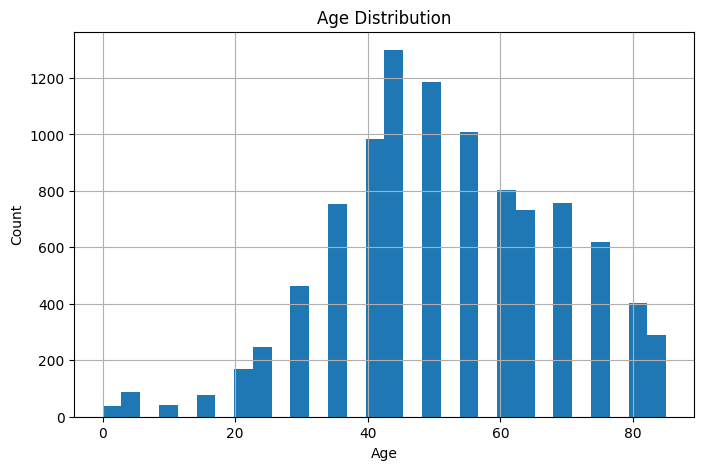

<Figure size 800x500 with 0 Axes>

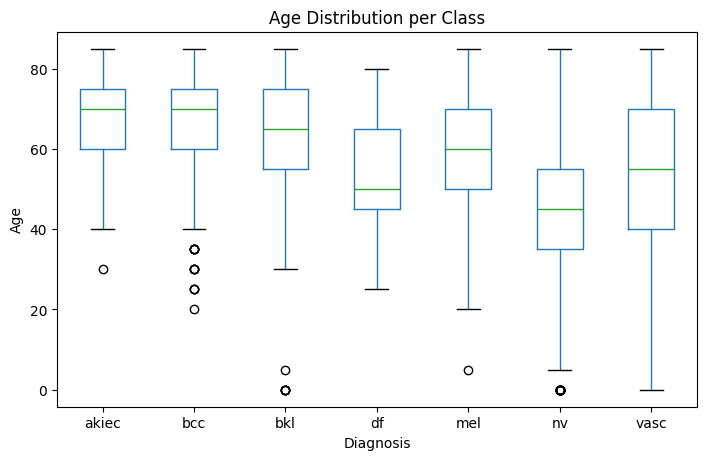

In [22]:
# ==============================
# 6. AGE ANALYSIS
# ==============================
plt.figure()
df['age'].dropna().hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


# Age per class
plt.figure()
df.boxplot(column='age', by='dx', grid=False)
plt.title('Age Distribution per Class')
plt.suptitle('')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.show()

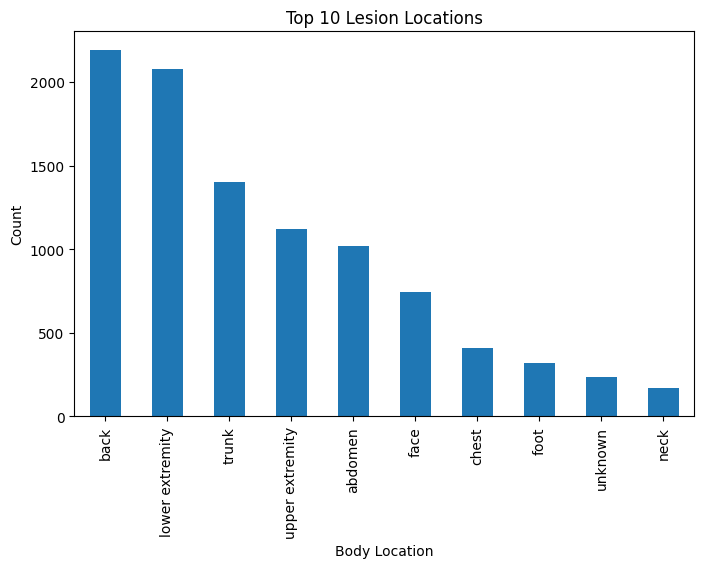

localization,abdomen,back,chest,face,foot,lower extremity,neck,trunk,unknown,upper extremity
dx,,,,,,,,,,
akiec,5,29,12,113,0,65,10,1,0,62
bcc,18,186,47,101,4,58,14,11,5,49
bkl,42,202,74,319,1,174,31,73,23,104
df,4,2,0,0,2,82,0,0,0,24
mel,66,324,68,104,28,192,29,47,10,213
nv,860,1427,200,100,284,1479,81,1241,196,655
vasc,27,22,6,8,0,27,3,31,0,11


In [23]:
# ==============================
# 7. LESION LOCALIZATION
# ==============================
loc_counts = df['localization'].value_counts().head(10)


plt.figure()
loc_counts.plot(kind='bar')
plt.title('Top 10 Lesion Locations')
plt.xlabel('Body Location')
plt.ylabel('Count')
plt.show()


# Class x Location (Top 5 locations)
top_locs = loc_counts.index.tolist()
df_loc = df[df['localization'].isin(top_locs)]
loc_class = pd.crosstab(df_loc['dx'], df_loc['localization'])
display(loc_class)

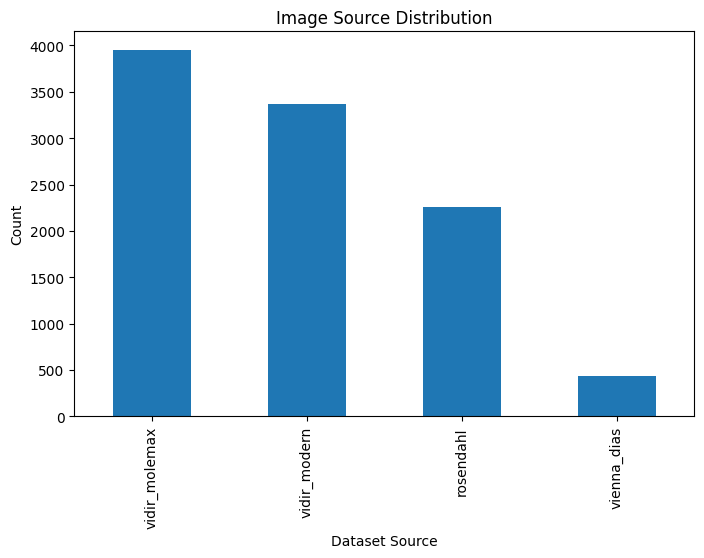

dataset,rosendahl,vidir_modern,vidir_molemax,vienna_dias
dx,,,,
akiec,295,32,0,0
bcc,296,211,2,5
bkl,490,475,124,10
df,30,51,30,4
mel,342,680,24,67
nv,803,1832,3720,350
vasc,3,82,54,3


In [24]:
# ==============================
# 8. DATASET SOURCE ANALYSIS
# ==============================
source_counts = df['dataset'].value_counts()


plt.figure()
source_counts.plot(kind='bar')
plt.title('Image Source Distribution')
plt.xlabel('Dataset Source')
plt.ylabel('Count')
plt.show()


source_class = pd.crosstab(df['dx'], df['dataset'])
display(source_class)

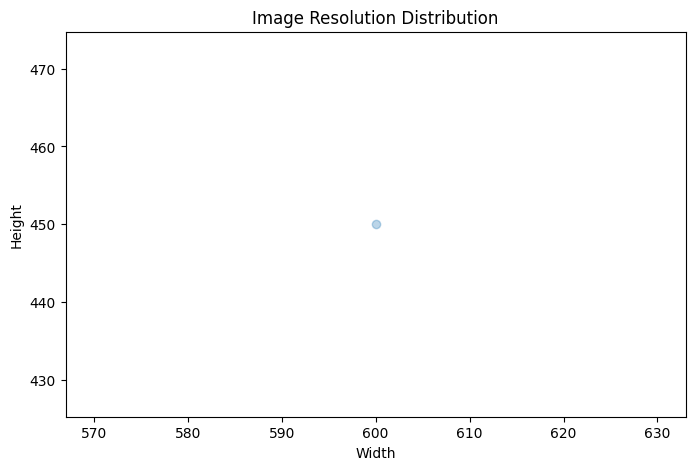

In [27]:
# ==============================
# 9. IMAGE SIZE ANALYSIS
# ==============================
def load_image(image_id):
    fname = image_id + '.jpg'
    for d in IMG_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return Image.open(p)
    return None


sizes = []
for img_id in df['image_id'].sample(500, random_state=42):
    img = load_image(img_id)
if img:
    sizes.append(img.size)


sizes = np.array(sizes)


plt.figure()
plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.3)
plt.title('Image Resolution Distribution')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

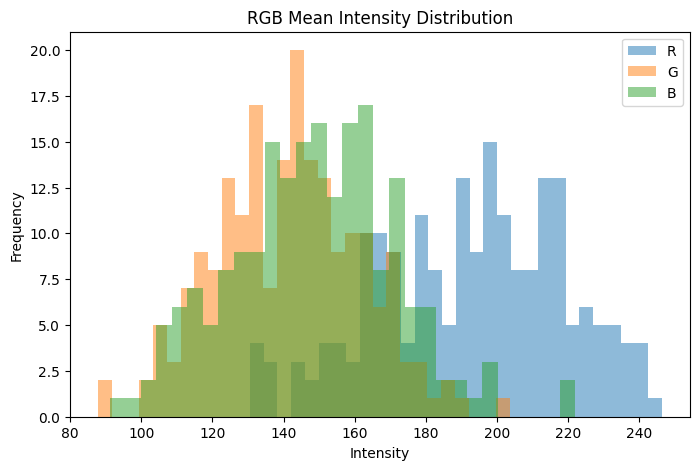

In [28]:
# ==============================
# 10. COLOR DISTRIBUTION (RGB MEAN)
# ==============================
means = []
for img_id in df['image_id'].sample(200, random_state=42):
    img = load_image(img_id)
    if img:
        arr = np.array(img)
        means.append(arr.mean(axis=(0, 1)))


means = np.array(means)


plt.figure()
plt.hist(means[:, 0], bins=30, alpha=0.5, label='R')
plt.hist(means[:, 1], bins=30, alpha=0.5, label='G')
plt.hist(means[:, 2], bins=30, alpha=0.5, label='B')
plt.legend()
plt.title('RGB Mean Intensity Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

In [29]:
# ==============================
# 11. MISSING VALUE ANALYSIS
# ==============================
missing_ratio = df.isnull().mean() * 100
display(missing_ratio)

lesion_id       0.000000
image_id        0.000000
dx              0.000000
dx_type         0.000000
age             0.569146
sex             0.000000
localization    0.000000
dataset         0.000000
dtype: float64

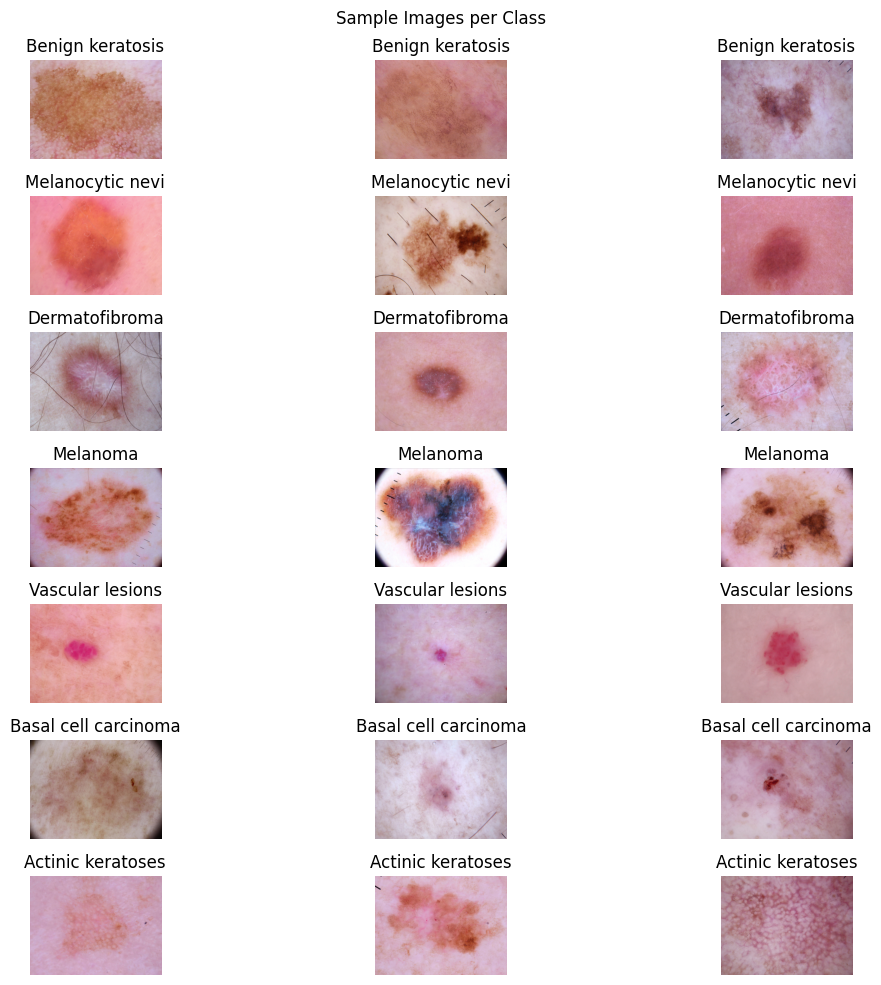

In [30]:
# ==============================
# 12. SAMPLE IMAGES PER CLASS
# ==============================
CLASS_MAP = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}


plt.figure(figsize=(12, 10))
i = 1
for dx in df['dx'].unique():
    subset = df[df['dx'] == dx].sample(3, random_state=42)
    for _, row in subset.iterrows():
        img = load_image(row['image_id'])
        if img:
            plt.subplot(7, 3, i)
            plt.imshow(img)
            plt.axis('off')
            plt.title(CLASS_MAP[dx])
            i += 1


plt.suptitle('Sample Images per Class')
plt.tight_layout()
plt.show()

In [33]:
# ==============================
# 13. SUMMARY TABLE
# ==============================
summary = df.groupby('dx').agg(
    num_images=('image_id', 'count'),
    age_mean=('age', 'mean'),
    age_std=('age', 'std'),
)

display(summary)

,num_images,age_mean,age_std
dx,,,
akiec,327,66.529052,11.476232
bcc,514,66.828794,13.656959
bkl,1099,64.283747,14.120715
df,115,53.043478,13.551326
mel,1113,60.679568,15.189847
nv,6705,46.477477,15.183275
vasc,142,51.373239,21.644651


In [32]:
# ==============================
# 14. EDA CONCLUSION (Markdown)
# ==============================
print("""
EDA Conclusions:
- Severe class imbalance exists in HAM10000.
- Demographic bias observed in age and sex.
- Multiple data sources introduce domain shift.
- Image resolution and color distribution vary significantly.
- GAN-based augmentation is justified to improve minority classes.
""")


EDA Conclusions:
- Severe class imbalance exists in HAM10000.
- Demographic bias observed in age and sex.
- Multiple data sources introduce domain shift.
- Image resolution and color distribution vary significantly.
- GAN-based augmentation is justified to improve minority classes.

